# Student Productivity Prediction

You have 1,500 student records. Predict `productivity_score` using a Linear Regression and a
Decision Tree, then compare the two.

This template is here for convenience. You are not required to follow this structure, but if you
do change it, keep the plot filenames and the metric output the same so your submission is easy to read.

## 1. Setup

Run this cell first. It imports everything you need and sets up two small helpers:

- `save_plot(name)` writes the current figure into a `plots/` folder with the filename we ask for.
- `report_metrics(name, y_true, y_pred)` prints R2, MAE and RMSE in a consistent format and remembers
  the numbers so you can compare models later.

In [356]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

PLOTS = Path('plots')
PLOTS.mkdir(exist_ok=True)


def save_plot(name):
    """Save the current figure to plots/<name>.png, then show it.

    Call this instead of plt.show(). Use the exact names listed in each section.
    """
    path = PLOTS / f'{name}.png'
    plt.savefig(path, dpi=150, bbox_inches='tight')
    print(f'saved -> {path}')
    plt.show()


results = {}


def report_metrics(name, y_true, y_pred, store=True):
    """Print R2, MAE and RMSE for one set of predictions."""
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))

    print(f'{name}')
    print(f"{'-' * len(name)}")
    print(f'  R2    {r2:>8.4f}')
    print(f'  MAE   {mae:>8.3f}  productivity points')
    print(f'  RMSE  {rmse:>8.3f}  productivity points')
    print()

    if store:
        results[name] = {'R2': r2, 'MAE': mae, 'RMSE': rmse}
    return {'R2': r2, 'MAE': mae, 'RMSE': rmse}

## 2. Load and explore the data

Load the CSV, look at the first few rows, check the shape, print summary statistics, and make the
two plots below.

Plots to save from this section:

- `save_plot('study_hours_vs_productivity')` - scatter of `study_hours_per_day` against `productivity_score`
- `save_plot('correlation_heatmap')` - correlation heatmap of every column

In [357]:
df = pd.read_csv('data.csv')

df.head()

,age,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,attendance_percentage,stress_level,assignments_completed,productivity_score
0,21,2.9,8.3,4.0,3.2,90.6,3,7,46.0
1,21,4.4,3.8,5.9,4.1,50.6,4,9,31.9
2,22,3.4,6.4,6.5,5.2,63.3,4,3,40.5
3,22,1.7,6.4,3.8,2.5,92.7,7,15,43.9
4,19,4.4,4.8,2.8,2.7,77.5,10,22,51.3


In [374]:
# Shape
print(f'Test data has {df.shape[0]} entries and {df.shape[1]} parameters.')

# Data Types
display(df.dtypes.to_frame('Data Types'))

# Summary Statistics
display(df.describe().T)

Test data has 1500 entries and 9 parameters.


,Data Types
age,int64
study_hours_per_day,float64
sleep_hours,float64
phone_usage_hours,float64
social_media_hours,float64
attendance_percentage,float64
stress_level,int64
assignments_completed,int64
productivity_score,float64


,count,mean,std,min,25%,50%,75%,max
age,1500.0,20.987333,2.012098,18.0,19.000,21.0,23.0,24.0
study_hours_per_day,1500.0,4.113267,1.733396,0.5,2.900,4.1,5.3,9.7
sleep_hours,1500.0,6.515000,1.490198,3.0,5.500,6.5,7.5,10.0
phone_usage_hours,1500.0,3.946200,1.464052,0.5,3.000,4.0,4.9,8.0
social_media_hours,1500.0,2.747600,1.107016,0.2,2.000,2.8,3.5,6.0
attendance_percentage,1500.0,74.455733,14.915618,20.0,64.075,74.5,85.6,100.0
stress_level,1500.0,5.506000,2.858101,1.0,3.000,5.0,8.0,10.0
assignments_completed,1500.0,15.908667,7.882750,3.0,9.000,16.0,23.0,29.0
productivity_score,1500.0,51.370400,12.604021,8.0,42.675,51.3,60.2,93.0


saved -> plots/study_hours_vs_productivity.png


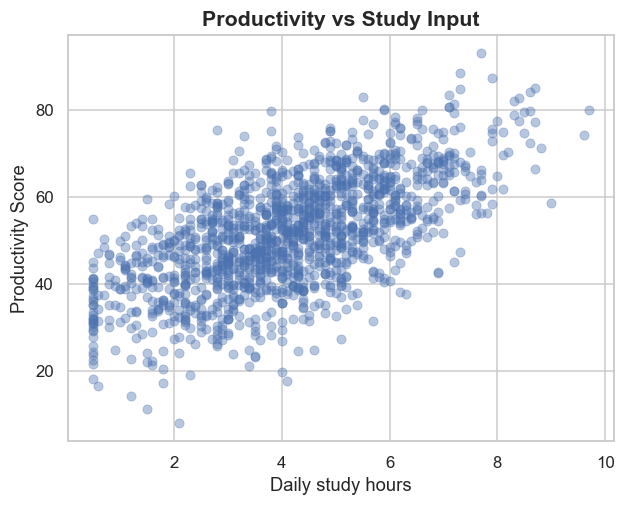

In [359]:
# Scatter: study_hours_per_day vs productivity_score
# Label both axes and give the plot a title before saving.

sns.scatterplot(data=df,
                x='study_hours_per_day',
                y='productivity_score',
                edgecolor=None,
                alpha=0.4)
plt.title('Productivity vs Study Input', fontsize=14, fontweight='bold')
plt.xlabel('Daily study hours')
plt.ylabel('Productivity Score')

save_plot('study_hours_vs_productivity')

saved -> plots/correlation_heatmap.png


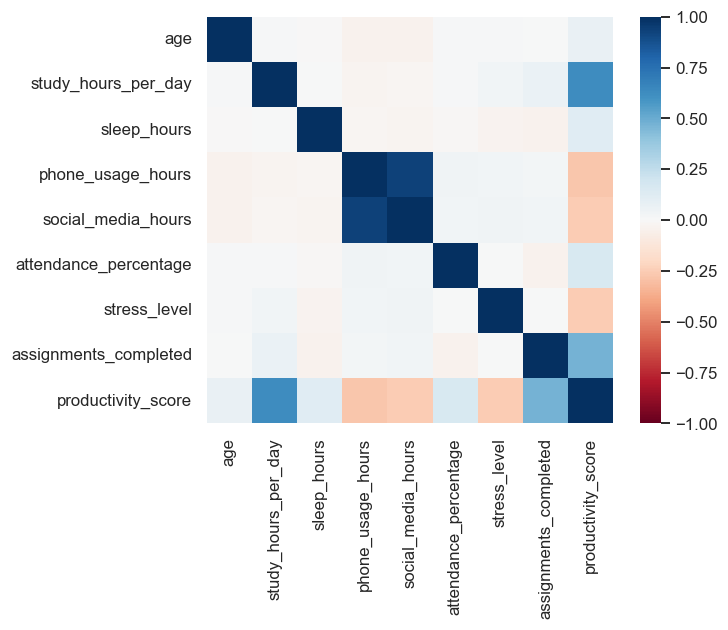

In [360]:
# Correlation heatmap
corr = df.corr()
sns.heatmap(corr, cmap='RdBu', vmin=-1, vmax=1, square=True)
save_plot('correlation_heatmap')

**Your observations** (two or three of them):

- Study hours per day most positively correlate with productivity score. Assignments completed also positively correlate to productivity score. However, sleep hours and attendance suprisingly dont contribute as much as study hours and assignments.

- Phone usage hours and social media hours correlate strongly, and can be practically assumed to carry identical information. Almost all the hours spent using the phone by the students is dedicated to social media.

- The entire column for age is almost entirely white, indicating that age has practically no correlation to other metrics like stress, attendance, productivity etc.

## 3. Prepare the data

Split into features (`X`) and target (`y`), then into train and test sets.
Use `test_size=0.2` and `random_state=42` so your numbers match everyone else's.

In [361]:
# Separate features and target

X = df.drop(columns=['productivity_score'])
y = df['productivity_score']

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

# # Checking correlation of social_media_hours and phone_usage_hours
# r = df['social_media_hours'].corr(df['phone_usage_hours'])
# print(r)

(1200, 8) (300, 8)
(1200,) (300,)


## 4. Linear Regression

Train the model, predict on the test set, and report the metrics with `report_metrics`.
Then print the coefficients next to their feature names.

In [362]:
# Create and train the model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict on the test set
lr_pred = lr.predict(X_test)

report_metrics('Linear Regression', y_test, lr_pred)

Linear Regression
-----------------
  R2      0.7503
  MAE      4.649  productivity points
  RMSE     5.954  productivity points



{'R2': 0.7502597300435191, 'MAE': 4.649123470868335, 'RMSE': 5.954189825457365}

In [363]:
# Coefficients, paired with feature names.
# A small DataFrame sorted by coefficient reads better than a raw array.

coef_df = {
    'features': X.columns,
    'coefficients': lr.coef_
}

coef_df = pd.DataFrame(coef_df).sort_values(by='coefficients', ignore_index=True, ascending=False)
display(coef_df)


,features,coefficients
0,study_hours_per_day,4.388014
1,sleep_hours,1.094580
2,assignments_completed,0.714395
3,social_media_hours,0.326770
4,age,0.306483
5,attendance_percentage,0.154087
6,stress_level,-1.219073
7,phone_usage_hours,-2.621974


**Interpret at least two coefficients in plain English.**

- Each extra hour of study per day, keeping other factors constant, increases your productivity score by ~4.4 points, and is the best way to increase your productivity.

- Attendance barely improves your productivity score, with each percentage point of attendance improving productivity by just 0.15 points.

- Using your phone/social media one hour per day drops your productivity by ~2.6 points.

## 5. Decision Tree

Same three metrics, then a picture of the tree. Keep `max_depth` small in the plot or it will be
unreadable.

Plot to save from this section:

- `save_plot('decision_tree')`

In [364]:
# Create and train the tree (start with max_depth=5)
dt = DecisionTreeRegressor(max_depth=8, min_samples_leaf=15,)    
dt.fit(X_train, y_train)

# Predict on the test set
dt_pred = dt.predict(X_test)

report_metrics('Decision Tree', y_test, dt_pred)

Decision Tree
-------------
  R2      0.5529
  MAE      6.223  productivity points
  RMSE     7.966  productivity points



{'R2': 0.5529473237418893, 'MAE': 6.222637095021368, 'RMSE': 7.96631981213835}

saved -> plots/decision_tree.png


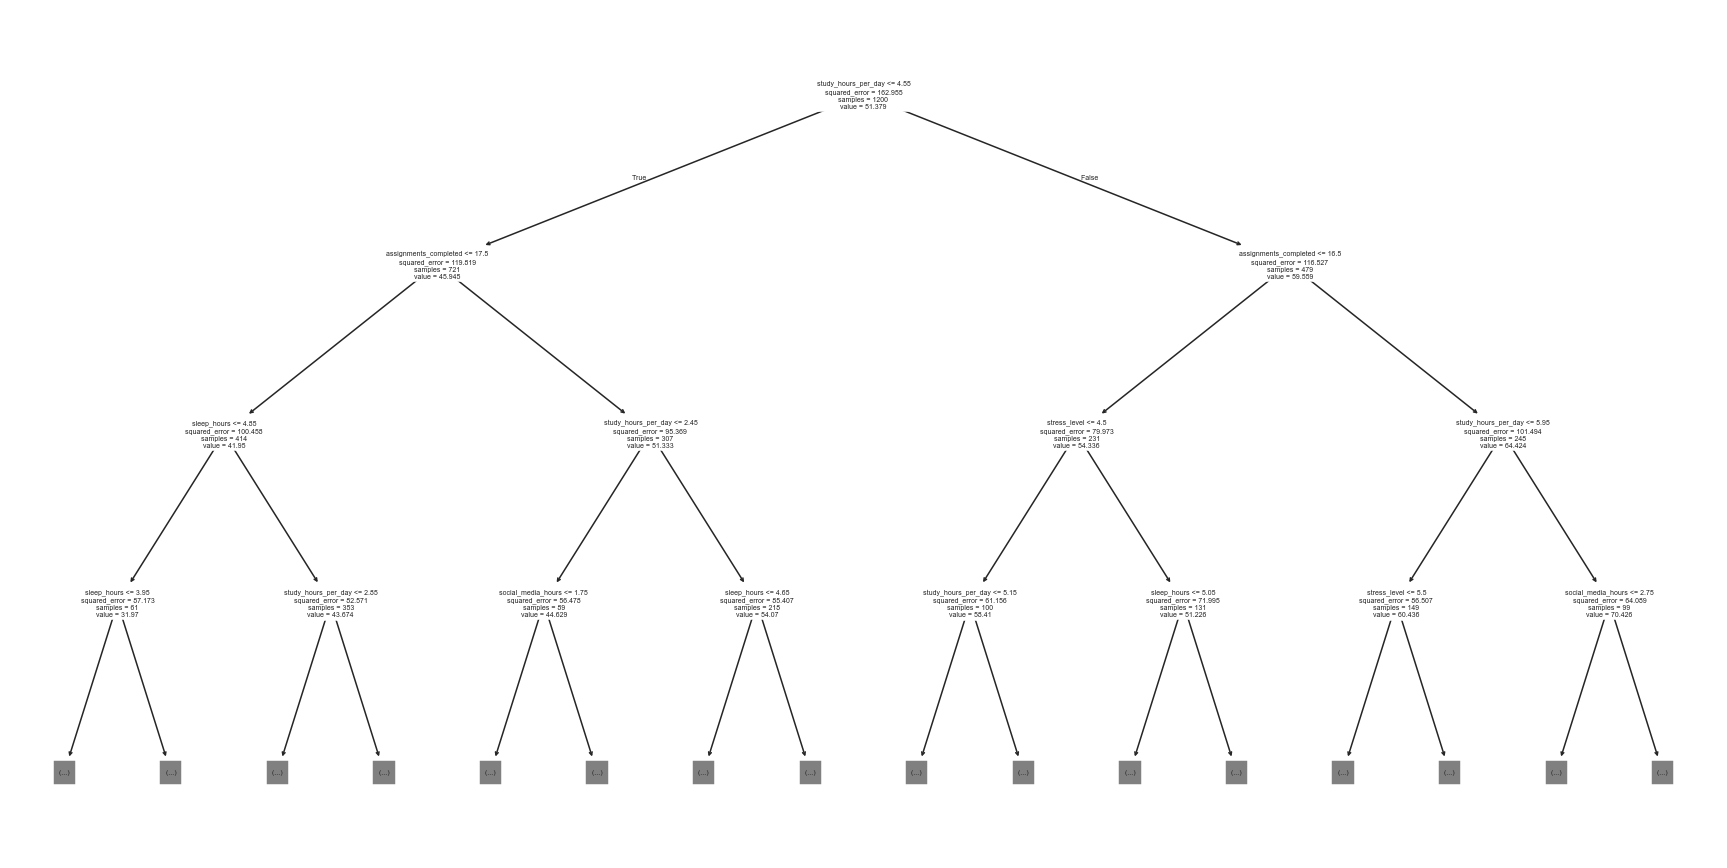

In [385]:
# Visualise the tree. A large figsize and max_depth=3 keeps it readable.
plt.figure(figsize=(20, 10))
plot_tree(dt, max_depth=3, feature_names=X.columns)

# Save the file as svg for better readability, and as png for submission
plt.savefig('decision_tree_svg.svg', format='svg', bbox_inches='tight')
save_plot('decision_tree')


## 6. Compare the two models

The `results` dictionary already holds the metrics from both `report_metrics` calls, so the
comparison table below needs nothing from you. The plot does.

Plot to save from this section:

- `save_plot('actual_vs_predicted')` - one figure, two panels side by side, one per model

In [366]:
comparison = pd.DataFrame(results).T.round(3)
display(comparison)

,R2,MAE,RMSE
Linear Regression,0.750,4.649,5.954
Decision Tree,0.553,6.223,7.966


saved -> plots/actual_vs_predicted.png


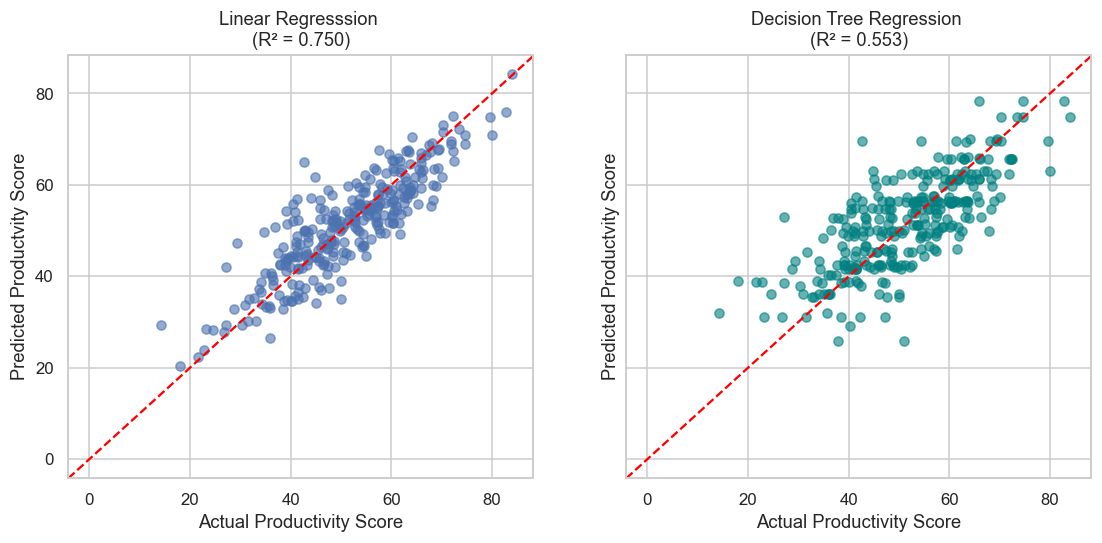

In [367]:
# Actual vs predicted, both models side by side.
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

axes[0].scatter(y_test, lr_pred, alpha=0.6)
axes[0].set_xlabel('Actual Productivity Score')
axes[0].set_ylabel('Predicted Productvity Score')
axes[0].set_title(f'Linear Regresssion \n(R² = {lr.score(X_test, y_test):.3f})')

axes[1].set_xlabel('Actual Productivity Score')
axes[1].scatter(y_test, dt_pred, alpha=0.6, color='teal')
axes[1].set_ylabel('Predicted Productvity Score')
axes[1].set_title(f'Decision Tree Regression \n(R² = {dt.score(X_test, y_test):.3f})')

# Plot the perfect-prediction diagonal on each panel so the reader has a reference line.
axes[0].axline((0,0), slope=1, color='red', linestyle='--')
axes[1].axline((0,0), slope=1, color='red', linestyle='--')

save_plot('actual_vs_predicted')


**Which model is better for this dataset, and why?** Tie your reasoning to specific patterns you
saw in the data, not to general statements about how the two algorithms work.

Your answer: The **Linear Regression** model is better for this dataset. It has a higher Coefficient of Determination(R²) of 0.75 as compared to Decision Tree Regression's R² value of 0.553. The data follows a somewhat linear relation between some parameters(for eg., study hours, sleep hours, assignments completed etc.) and the productivity score, favoring the linear model. The decision tree regression has many off diagonal outliers.

## 7. Understanding checks

These are worth 30 percent of the score, and you may be asked about them face to face.

**Q1.** What does the `study_hours_per_day` coefficient mean in plain English?

Your answer:  Looking at the mathematical equation for a linear regression model, $$Y = \beta_{0} + \beta_{1}X,$$ $\beta_{1}$ represents the coeffecient for a feature $X$ in the dataset. Or, $\beta_{1}$ measures the amount of change in the value of $Y$, the target variable per unit change in $X$, the feature.

In plain english, the `study_hours_per_day` coefficient measures the expected increase/decrease in the productivity score per hour of study per day, keeping all other factors constant.

**Q2.** Compare the sign of the `social_media_hours` coefficient with the sign of its correlation
against `productivity_score`. Do they match? If not, why might that be?

Your answer: No, they dont match. It might be due to the very high correlation of `social_media_hours` and `phone_usage_hours`, practically conveying the same information. The model gives a large negative weight to `phone_usage_hours` but cannot give the same negative weight to `social_media_hours`, or it would overcompensate, as both occur almost simultaneously. It might be that when the a few data points have less `social_media_hours` and higher `phone_usage_hours`, the productivity dropped more, and the model then associated lower `social_media_hours` with lower productivity, thus giving it a positive weight.

In [368]:
# Working for Q2: coefficient, correlation with the target, correlation with other features
social_media_hours_coeff = float(coef_df['coefficients'][3])
corr_coeff = float(df['social_media_hours'].corr(df['productivity_score']))

print(f'Regression coefficient of social_media_hours: {social_media_hours_coeff:.3f}')
print(f'Correlation coefficient of social_media_hours and productivity_score: {corr_coeff:.3f}')

Regression coefficient of social_media_hours: 0.327
Correlation coefficient of social_media_hours and productivity_score: -0.254


value at the leaf, and whether it matches what the model predicts for that row.

Your answer: Row 67 from the test set has:
- `study_hours_per_day` = 3.8
- `assignments_completed` = 9
- `sleep_hours` = 5.2
- `social_media_hours` = 1.8

Tracing through the tree:

1. **Node 0**: `study_hours_per_day <= 4.55`?
    - 3.8 <= 4.55 → **True**, go left

2. **Node 1**: `assignments_completed <= 17.50`?
    - 9 <= 17.50 → **True**, go left

3. **Node 2**: `sleep_hours <= 4.85`?
    - 5.2 <= 4.85 → **False**, go right

4. **Node 3**: `study_hours_per_day <= 2.85`?
    - 3.8 <= 2.85 → **False**, go right

5. **Node 4**: `stress_level <= 4.50`?
    - stress_level = 4 <= 4.50 → **True**, go left

6. **Node 5**: `assignments_completed <= 7.50`?
    - 9 <= 7.50 → **False**, go right

7. **Leaf**: **value = [50.01]**

The model predicts a productivity score of **50.01**, which closely matches the actual leaf value of 50.01. The hand trace confirms the model's decision path is working correctly.

In [388]:
# Working for Q3: print the row, then the model's prediction for it
# X_row = np.reshape(df.iloc[1].iloc[:-1], (1,8))
X_row = df.iloc[[67]]
display(X_row)
pred = float(lr.predict(X_row.drop(columns=['productivity_score']))[0])
print(f"Model's productivity score prediction: {pred}")

,age,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,attendance_percentage,stress_level,assignments_completed,productivity_score
67,20,3.8,5.2,1.8,1.8,60.7,8,9,43.4


Model's productivity score prediction: 43.48176117903206


In [386]:
# Printing decision tree in text format 
from sklearn.tree import export_text
tree_rules = export_text(dt, feature_names=X_train.columns, max_depth=8)
print("--- DECISION TREE RULES ---")
print(tree_rules)


--- DECISION TREE RULES ---
|--- study_hours_per_day <= 4.55
|   |--- assignments_completed <= 17.50
|   |   |--- sleep_hours <= 4.85
|   |   |   |--- sleep_hours <= 3.95
|   |   |   |   |--- value: [25.84]
|   |   |   |--- sleep_hours >  3.95
|   |   |   |   |--- social_media_hours <= 3.35
|   |   |   |   |   |--- value: [38.60]
|   |   |   |   |--- social_media_hours >  3.35
|   |   |   |   |   |--- value: [31.02]
|   |   |--- sleep_hours >  4.85
|   |   |   |--- study_hours_per_day <= 2.85
|   |   |   |   |--- social_media_hours <= 2.35
|   |   |   |   |   |--- study_hours_per_day <= 1.60
|   |   |   |   |   |   |--- value: [38.66]
|   |   |   |   |   |--- study_hours_per_day >  1.60
|   |   |   |   |   |   |--- attendance_percentage <= 75.90
|   |   |   |   |   |   |   |--- value: [43.29]
|   |   |   |   |   |   |--- attendance_percentage >  75.90
|   |   |   |   |   |   |   |--- value: [50.22]
|   |   |   |   |--- social_media_hours >  2.35
|   |   |   |   |   |--- study_hours_per

**Q4.** Drop `social_media_hours` and retrain the Linear Regression. What happens to R2, and why?

Your answer: The R2 barely changes, dropping by 0.0004 points, which is practically insignificant. It is bound to decrease on decreasing the number of features. The reason it barely changes is due to the fact that `social_media_hours` had major overlap with `phone_usage_hours`, essentially conveying the same information. 

In [370]:
# Working for Q4. Use report_metrics(..., store=False) so this does not land in the
# comparison table above.
X1 = df.drop(columns=['social_media_hours', 'productivity_score'])
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y, random_state=42, test_size=0.2)

lr1 = LinearRegression()
lr1.fit(X1_train, y1_train)


lr1_pred = lr1.predict(X1_test)
report_metrics('Modified Linear Regression', y_test, lr1_pred, store=False)


Modified Linear Regression
--------------------------
  R2      0.7496
  MAE      4.651  productivity points
  RMSE     5.962  productivity points



{'R2': 0.749566852768395, 'MAE': 4.650846919447762, 'RMSE': 5.962443731267682}

**Q5.** Is the relationship between `sleep_hours` and `productivity_score` a straight line, or is
something else going on?

Plot to save from this question:

- `save_plot('sleep_hours_vs_productivity')`

Your answer:

saved -> plots/sleep_hours_vs_productivity.png


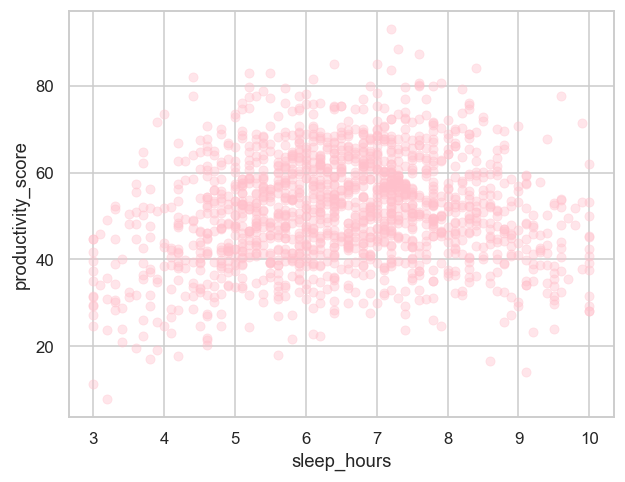

In [371]:
# Scatter: sleep_hours vs productivity_score
sns.scatterplot(data=df,
                x='sleep_hours',
                y='productivity_score',
                color='pink',
                edgecolor=None,
                alpha=0.4)
save_plot('sleep_hours_vs_productivity')

**Q6.** Set `max_depth=None` and compare the training R2 with the test R2. What happens, and what
is this called?

Your answer: It has a perfect R2 value of 1.0 on training data but it drops sharply on the test data, which it has not seen before. Since the `max_dept` was set to `None`, the model fitted each and every data point, causing it to memorize the training data, instead of actually finding a pattern in it. This is called overfitting.

In [372]:
# Working for Q6. Report training and test scores separately, with store=False.
dt1 = DecisionTreeRegressor(max_depth=None)
dt1.fit(X_train, y_train)

dt1_train_pred = dt1.predict(X_train)
dt1_test_pred = dt1.predict(X_test)

report_metrics('dt1_train', y_train, dt1_train_pred, store=False)
report_metrics('dt1_test', y_test, dt1_test_pred, store=False)



dt1_train
---------
  R2      1.0000
  MAE      0.000  productivity points
  RMSE     0.000  productivity points

dt1_test
--------
  R2      0.4339
  MAE      6.975  productivity points
  RMSE     8.965  productivity points



{'R2': 0.4338543348338837, 'MAE': 6.975333333333333, 'RMSE': 8.96483872321936}

**Q7.** A friend says: "Social media is good for productivity, because the coefficient is
positive." Is that right? Two or three sentences.

Your answer: **No**, that is incorrect. The positive coefficient in a multiple linear regression model doesnt imply a positive effect on actual productivity. The model's weights were distorted by the heavy multicollinearity of `phone_usage_hours` and `social_media_hours`, causing it to assign a large negative weight to `phone_usage_hours` but a positive weight to `social_media_hours` to mathematically prevent double counting. 

## 8. Reflection

Where did AI tools help you, and where did they hand you something wrong or misleading? Be specific,
a sentence about an actual moment is worth more than a general statement.

Your answer: AI tools, mostly Gemini, helped me in _pandas_ and _matplotlib_ syntax a lot, as I wasnt familiar with those modules until now. Also, I learned other new concepts not mentioned in this repo, such as overfitting and multicollinearity. But AI also has its pitfalls, due to its lack of context, when i got stuck on trying to pass a 1D array into the `lr` model's prediction, and Gemini kept telling me to convert it into a 2D array using some other modules. Alas i had to use youtube to learn the syntax of sklearn linear regression models. Also, it always over-generalises and over-explains even simple stuff, like claiming that "suppressor effects" and "confounding" were causing the sign flip in the correlation coefficeint vs the linear regression coefficient. 

## 9. Before you submit

Run this last. It checks that every plot we asked for actually exists in `plots/`.

In [373]:
expected = [
    'study_hours_vs_productivity',
    'correlation_heatmap',
    'decision_tree',
    'actual_vs_predicted',
    'sleep_hours_vs_productivity',
]

missing = [name for name in expected if not (PLOTS / f'{name}.png').exists()]

for name in expected:
    mark = ' ' if name in missing else 'x'
    print(f'[{mark}] {name}.png')

print()
print('All plots saved.' if not missing else f'Still missing: {", ".join(missing)}')

print()
print('Also remember to submit:')
print('  - this notebook, with the outputs left in')
print('  - the plots/ folder')
print('  - your one-page written report')

[x] study_hours_vs_productivity.png
[x] correlation_heatmap.png
[x] decision_tree.png
[x] actual_vs_predicted.png
[x] sleep_hours_vs_productivity.png

All plots saved.

Also remember to submit:
  - this notebook, with the outputs left in
  - the plots/ folder
  - your one-page written report
